In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from scipy.optimize import minimize
import warnings
import pandas as pd
import os
warnings.filterwarnings("ignore")
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CONFIG={
    "n_samples": 500,
    "noise_level":0.02,
    "seed": SEED,
}

TRUE_FORMULAS={
    "qho":       "E = omega * (n + 1/2)",
    "hydrogen":  "E = -1 / n^2",
    "debroglie": "lambda = 1 / p",
}

print("Tensorflow: ", tf.__version__)
print("Numpy: ", np.__version__)
print("Seeds set. config loaded.")

Tensorflow:  2.21.0
Numpy:  2.4.6
Seeds set. config loaded.


In [3]:
def generate_qho(n_samples=500, noise_level=0.02, seed=42):
    """Quantum harmonic oscillator: E = omega * (n + 1/2). Features: [n, omega]."""
    rng = np.random.default_rng(seed)
    n = rng.integers(0, 11, size=n_samples).astype(np.float32)
    omega = rng.uniform(0.5, 3.0, size=n_samples).astype(np.float32)
    E_clean = omega * (n + 0.5)
    noise = rng.normal(0, noise_level * np.abs(E_clean)).astype(np.float32)
    E = E_clean + noise
    X = np.stack([n, omega], axis=1)
    return X, E

def generate_hydrogen(n_samples=500, noise_level=0.02, seed=42):
    """Hydrogen energy levels: E = -1/n^2. Features: [n]. Units: Rydberg."""
    rng = np.random.default_rng(seed + 1)   # offset seed per dataset
    n = rng.integers(1, 16, size=n_samples).astype(np.float32)
    E_clean = -1.0 / (n ** 2)
    noise = rng.normal(0, noise_level * np.abs(E_clean)).astype(np.float32)
    E = E_clean + noise
    X = n.reshape(-1, 1)
    return X, E

def generate_debroglie(n_samples=500, noise_level=0.02, seed=42):
    """De Broglie: lambda = 1/p. Features: [p]. Units: h = 1."""
    rng = np.random.default_rng(seed + 2)
    p = rng.uniform(0.1, 10.0, size=n_samples).astype(np.float32)
    lam_clean = 1.0 / p
    noise = rng.normal(0, noise_level * np.abs(lam_clean)).astype(np.float32)
    lam = lam_clean + noise
    X = p.reshape(-1, 1)
    return X, lam

X_qho, y_qho = generate_qho(**CONFIG)
X_hyd, y_hyd = generate_hydrogen(**CONFIG)
X_deb, y_deb = generate_debroglie(**CONFIG)

print("QHO       :", X_qho.shape, "->", y_qho.shape)
print("Hydrogen  :", X_hyd.shape, "->", y_hyd.shape)
print("De Broglie:", X_deb.shape, "->", y_deb.shape)

QHO       : (500, 2) -> (500,)
Hydrogen  : (500, 1) -> (500,)
De Broglie: (500, 1) -> (500,)


In [4]:
df_qho = pd.DataFrame({"n": X_qho[:, 0], "omega": X_qho[:, 1], "E": y_qho})
df_hyd = pd.DataFrame({"n": X_hyd[:, 0], "E": y_hyd})
df_deb = pd.DataFrame({"p": X_deb[:, 0], "lambda": y_deb})

df_qho.to_csv("../data/qho.csv", index=False)
df_hyd.to_csv("../data/hydrogen.csv", index=False)
df_deb.to_csv("../data/debroglie.csv", index=False)

print("QHO head:")
print(df_qho.head(), "\n")
print("Hydrogen head:")
print(df_hyd.head(), "\n")
print("De Broglie head:")
print(df_deb.head(), "\n")

print("Summary statistics (QHO):")
print(df_qho.describe(), "\n")

print("Saved three CSVs to data/")

QHO head:
     n     omega          E
0  0.0  2.129827   1.062865
1  8.0  2.668727  23.195942
2  7.0  1.634742  11.701303
3  4.0  1.119599   4.887388
4  4.0  1.091656   4.821779 

Hydrogen head:
      n         E
0   8.0 -0.015783
1  10.0 -0.010135
2   7.0 -0.020351
3   1.0 -1.001470
4   9.0 -0.012371 

De Broglie head:
          p    lambda
0  1.313399  0.775026
1  2.655319  0.378849
2  4.117130  0.243171
3  9.694921  0.102117
4  1.706940  0.589067 

Summary statistics (QHO):
               n       omega           E
count  500.00000  500.000000  500.000000
mean     4.99800    1.749700    9.555902
std      3.13267    0.730218    7.249304
min      0.00000    0.503083    0.261421
25%      2.00000    1.107734    3.660632
50%      5.00000    1.761322    7.744086
75%      8.00000    2.407895   13.792840
max     10.00000    2.997762   31.325661 

Saved three CSVs to data/


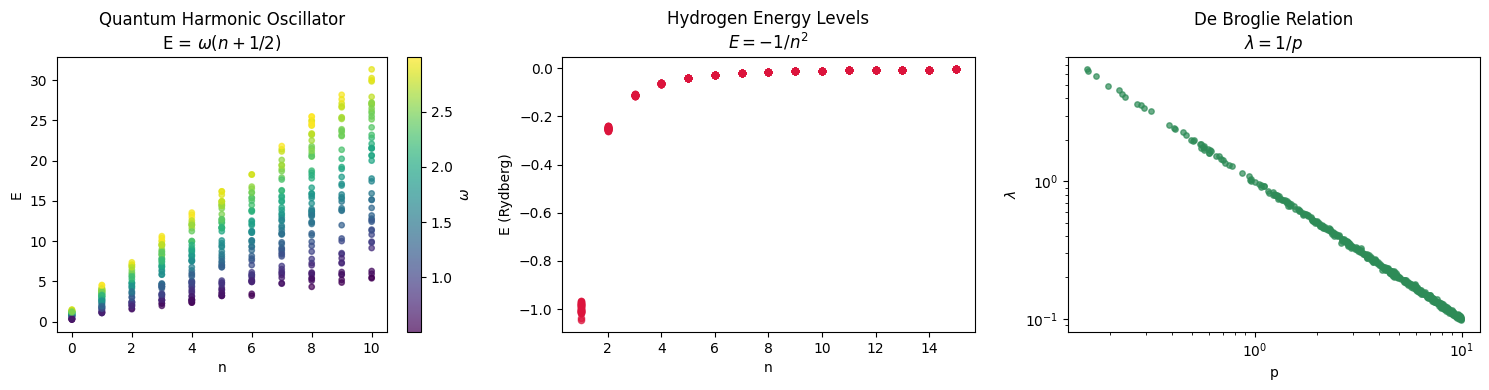

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc0 = axes[0].scatter(X_qho[:, 0], y_qho, c=X_qho[:, 1], cmap="viridis", s=15, alpha=0.7)
axes[0].set_xlabel("n")
axes[0].set_ylabel("E")
axes[0].set_title("Quantum Harmonic Oscillator\nE = $\\omega(n + 1/2)$")
plt.colorbar(sc0, ax=axes[0], label=r"$\omega$")

axes[1].scatter(X_hyd[:, 0], y_hyd, s=20, alpha=0.7, color="crimson")
axes[1].set_xlabel("n")
axes[1].set_ylabel("E (Rydberg)")
axes[1].set_title("Hydrogen Energy Levels\n$E = -1/n^2$")

axes[2].scatter(X_deb[:, 0], y_deb, s=15, alpha=0.7, color="seagreen")
axes[2].set_xlabel("p")
axes[2].set_ylabel(r"$\lambda$")
axes[2].set_title("De Broglie Relation\n$\\lambda = 1/p$")
axes[2].set_xscale("log")
axes[2].set_yscale("log")

plt.tight_layout()
plt.savefig("../figures/data_visualization.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
class EQLLayer(tf.keras.layers.Layer):
    """One block of the EQL network. Applies a linear projection to its input,
    then splits the projection across symbolic primitives and concatenates
    the results. Sparsity is enforced via an L1 penalty on the projection
    weights, accumulated externally via `self.W`."""
    def __init__(self, n_identity=4, n_sin=2, n_exp=2, n_inv=2, n_mul=2, **kwargs):
        super().__init__(**kwargs)
        self.n_identity=n_identity
        self.n_sin=n_sin
        self.n_exp=n_exp
        self.n_inv=n_inv
        self.n_mul=n_mul
    def build(self, input_shape):
        in_dim=input_shape[-1]
        # total slots = unary primitives + 2 * binary primitives
        self.n_unary = self.n_identity + self.n_sin + self.n_exp + self.n_inv
        self.n_slots = self.n_unary + 2 * self.n_mul
        self.W=self.add_weight(
            name="W",
            shape=(in_dim, self.n_slots),
            initializer=tf.keras.initializers.GlorotNormal(seed=SEED),
            trainable=True,
        )
        self.b = self.add_weight(
            name="b",
            shape=(self.n_slots,),
            initializer="zeros",
            trainable=True,
        )
    def call(self, x):
        z = tf.matmul(x, self.W) + self.b
        outputs = []
        idx = 0
        # identity
        if self.n_identity > 0:
            outputs.append(z[:, idx:idx + self.n_identity])
            idx += self.n_identity
        # sin
        if self.n_sin > 0:
            outputs.append(tf.sin(z[:, idx:idx + self.n_sin]))
            idx += self.n_sin
        # exp (clipped to avoid overflow / NaN)
        if self.n_exp > 0:
            clipped = tf.clip_by_value(z[:, idx:idx + self.n_exp], -10.0, 10.0)
            outputs.append(tf.exp(clipped))
            idx += self.n_exp
        # inverse (clipped denominator to avoid div-by-zero)
        if self.n_inv > 0:
            denom = z[:, idx:idx + self.n_inv]
            denom_safe = tf.where(
                tf.abs(denom) < 1e-3,
                tf.sign(denom + 1e-12) * 1e-3,
                denom,
                )
            outputs.append(1.0 / denom_safe)
            idx += self.n_inv
        # multiplication (pairs)
        if self.n_mul > 0:
            a = z[:, idx:idx + self.n_mul]
            b = z[:, idx + self.n_mul:idx + 2 * self.n_mul]
            outputs.append(a * b)
            idx += 2 * self.n_mul
        return tf.concat(outputs, axis=-1)
    def l1_penalty(self):
        """Sum of |W| — added to the loss to encourage sparse symbolic forms."""
        return tf.reduce_sum(tf.abs(self.W))
    def get_config(self):
        config = super().get_config()
        config.update({
            "n_identity": self.n_identity,
            "n_sin": self.n_sin,
            "n_exp": self.n_exp,
            "n_inv": self.n_inv,
            "n_mul": self.n_mul,
        })
        return config
print("EQLLayer defined.")           

EQLLayer defined.


In [7]:
test_layer = EQLLayer(n_identity=3, n_sin=2, n_exp=2, n_inv=2, n_mul=2)
test_input = tf.random.normal((8, 4))   # batch of 8, 4 input features
test_output = test_layer(test_input)

print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)
print()
print("Expected output dim = 3 (id) + 2 (sin) + 2 (exp) + 2 (inv) + 2 (mul) = 11")
print("Number of trainable weights:", sum([tf.size(w).numpy() for w in test_layer.trainable_weights]))
print("L1 penalty value:", test_layer.l1_penalty().numpy())

Input shape : (8, 4)
Output shape: (8, 11)

Expected output dim = 3 (id) + 2 (sin) + 2 (exp) + 2 (inv) + 2 (mul) = 11
Number of trainable weights: 65
L1 penalty value: 14.095552


In [8]:
class EQLModel(tf.keras.Model):
    """EQL network: stacked EQLLayer blocks followed by a linear output layer.
    The output layer is a Dense(1) that takes a sparse linear combination of
    the symbolic primitives produced by the last EQL block."""

    def __init__(self, input_dim, n_layers=2, layer_kwargs=None, **kwargs):
        super().__init__(**kwargs)
        layer_kwargs = layer_kwargs or {}
        self.eql_layers = [EQLLayer(**layer_kwargs) for _ in range(n_layers)]
        self.output_layer = tf.keras.layers.Dense(
            1,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.GlorotNormal(seed=SEED),
        )
        self.input_dim = input_dim

    def call(self, x):
        for layer in self.eql_layers:
            x = layer(x)
        return self.output_layer(x)

    def l1_penalty(self):
        total = tf.add_n([layer.l1_penalty() for layer in self.eql_layers])
        total += tf.reduce_sum(tf.abs(self.output_layer.kernel))
        return total


def build_eql_model(input_dim, n_layers=2, n_identity=4, n_sin=2,
                    n_exp=2, n_inv=2, n_mul=2):
    """Convenience factory. Builds and initializes the model so weights
    are allocated and ready to inspect."""
    layer_kwargs = dict(
        n_identity=n_identity, n_sin=n_sin,
        n_exp=n_exp, n_inv=n_inv, n_mul=n_mul,
    )
    model = EQLModel(input_dim=input_dim, n_layers=n_layers, layer_kwargs=layer_kwargs)
    _ = model(tf.zeros((1, input_dim)))   # forces weight allocation
    return model


print("EQLModel and build_eql_model defined.")

EQLModel and build_eql_model defined.


In [9]:
print("=== QHO model (input_dim=2) ===")
m_qho = build_eql_model(input_dim=2, n_layers=2)
print("Output for batch of 16:", m_qho(tf.random.normal((16, 2))).shape)
print("Total params:", m_qho.count_params())
print("L1 penalty:", m_qho.l1_penalty().numpy())
print()

print("=== Hydrogen model (input_dim=1) ===")
m_hyd = build_eql_model(input_dim=1, n_layers=2)
print("Output for batch of 16:", m_hyd(tf.random.normal((16, 1))).shape)
print("Total params:", m_hyd.count_params())
print("L1 penalty:", m_hyd.l1_penalty().numpy())
print()

print("=== De Broglie model (input_dim=1) ===")
m_deb = build_eql_model(input_dim=1, n_layers=2)
print("Output for batch of 16:", m_deb(tf.random.normal((16, 1))).shape)
print("Total params:", m_deb.count_params())
print("L1 penalty:", m_deb.l1_penalty().numpy())

=== QHO model (input_dim=2) ===
Output for batch of 16: (16, 1)
Total params: 237
L1 penalty: 48.42913

=== Hydrogen model (input_dim=1) ===
Output for batch of 16: (16, 1)
Total params: 223
L1 penalty: 43.692738

=== De Broglie model (input_dim=1) ===
Output for batch of 16: (16, 1)
Total params: 223
L1 penalty: 43.692738


In [10]:
def train_val_split(X, y, val_frac=0.2, seed=SEED):
    """Random train/val split. Returns X_train, y_train, X_val, y_val."""
    rng = np.random.default_rng(seed)
    n = len(y)
    idx = rng.permutation(n)
    n_val = int(n * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


def normalize_y(y_train, y_val, log_scale=False):
    """Z-score normalize y. If log_scale, applies log(|y|+eps) first —
    useful for targets spanning many orders of magnitude (de Broglie).
    Returns (y_train_norm, y_val_norm, stats_dict)."""
    y_tr = y_train.astype(np.float32).copy()
    y_va = y_val.astype(np.float32).copy()
    if log_scale:
        y_tr = np.log(np.abs(y_tr) + 1e-8)
        y_va = np.log(np.abs(y_va) + 1e-8)
    mean = float(y_tr.mean())
    std = float(y_tr.std()) + 1e-8
    return (y_tr - mean) / std, (y_va - mean) / std, {"mean": mean, "std": std, "log_scale": log_scale}


def denormalize_y(y_pred_norm, stats):
    """Invert normalize_y. Returns predictions in original units."""
    y = y_pred_norm * stats["std"] + stats["mean"]
    if stats["log_scale"]:
        y = np.exp(y)
    return y


print("Data prep utilities defined: train_val_split, normalize_y, denormalize_y.")

Data prep utilities defined: train_val_split, normalize_y, denormalize_y.


In [11]:
def train_eql(model, X_train, y_train, X_val, y_val,
              epochs=2000, batch_size=64, lr=1e-2,
              l1_lambda=1e-3, loss_type="huber",
              patience=200, clipnorm=1.0, verbose=200):
    """Custom training loop for an EQL model.

    Total loss = data_loss(y, preds) + l1_lambda * model.l1_penalty()

    - loss_type: 'huber' (default, robust to outliers) or 'mse'
    - clipnorm: gradient norm clipping in Adam, prevents NaN blow-ups
    - patience: early stop after this many epochs without val improvement
    - verbose: print every N epochs (set 0 to silence)

    Returns: history dict with loss curves and best epoch."""

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)

    if loss_type == "huber":
        data_loss_fn = tf.keras.losses.Huber(delta=1.0)
    elif loss_type == "mse":
        data_loss_fn = tf.keras.losses.MeanSquaredError()
    else:
        raise ValueError(f"unknown loss_type {loss_type}")

    X_train_t = tf.convert_to_tensor(X_train, dtype=tf.float32)
    y_train_t = tf.convert_to_tensor(y_train, dtype=tf.float32)
    X_val_t   = tf.convert_to_tensor(X_val,   dtype=tf.float32)
    y_val_t   = tf.convert_to_tensor(y_val,   dtype=tf.float32)

    n_train = len(y_train)
    history = {"train_loss": [], "val_loss": [], "l1": []}
    best_val, best_epoch, best_weights = np.inf, 0, None
    epochs_no_improve = 0

    @tf.function
    def train_step(xb, yb):
        with tf.GradientTape() as tape:
            preds = tf.squeeze(model(xb), axis=-1)
            data_loss = data_loss_fn(yb, preds)
            l1 = model.l1_penalty()
            total = data_loss + l1_lambda * l1
        grads = tape.gradient(total, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))
        return data_loss, l1

    for epoch in range(epochs):
        perm = tf.random.shuffle(tf.range(n_train))
        X_shuf = tf.gather(X_train_t, perm)
        y_shuf = tf.gather(y_train_t, perm)

        batch_losses = []
        for i in range(0, n_train, batch_size):
            xb = X_shuf[i:i + batch_size]
            yb = y_shuf[i:i + batch_size]
            dl, l1 = train_step(xb, yb)
            batch_losses.append(float(dl))

        val_preds = tf.squeeze(model(X_val_t), axis=-1)
        val_loss = float(data_loss_fn(y_val_t, val_preds))
        train_loss = float(np.mean(batch_losses))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["l1"].append(float(l1))

        if val_loss < best_val - 1e-6:
            best_val, best_epoch = val_loss, epoch
            best_weights = [w.numpy().copy() for w in model.trainable_weights]
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % verbose == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:4d}  train={train_loss:.5f}  val={val_loss:.5f}  L1={float(l1):.3f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"  early stop at epoch {epoch} (best val={best_val:.5f} at epoch {best_epoch})")
            break

    if best_weights is not None:
        for w, bw in zip(model.trainable_weights, best_weights):
            w.assign(bw)

    history["best_val"] = best_val
    history["best_epoch"] = best_epoch
    return history


print("train_eql defined.")

train_eql defined.


In [12]:
# --- QHO: prepare data ---
X_qho_tr, y_qho_tr, X_qho_va, y_qho_va = train_val_split(X_qho, y_qho, val_frac=0.2)
y_qho_tr_n, y_qho_va_n, qho_stats = normalize_y(y_qho_tr, y_qho_va, log_scale=False)

print(f"QHO train: {X_qho_tr.shape}, val: {X_qho_va.shape}")
print(f"y_train mean={qho_stats['mean']:.3f}, std={qho_stats['std']:.3f}")

# --- build model ---
np.random.seed(SEED); tf.random.set_seed(SEED)
model_qho = build_eql_model(input_dim=2, n_layers=2)
print(f"Built QHO model with {model_qho.count_params()} params.")

# --- train ---
print("\nTraining QHO EQL...")
history_qho = train_eql(
    model_qho, X_qho_tr, y_qho_tr_n, X_qho_va, y_qho_va_n,
    epochs=2000, batch_size=64, lr=1e-2,
    l1_lambda=1e-3, loss_type="huber",
    patience=200, clipnorm=1.0, verbose=200,
)

# --- evaluate ---
def r2_score(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

pred_tr_n = tf.squeeze(model_qho(X_qho_tr), axis=-1).numpy()
pred_va_n = tf.squeeze(model_qho(X_qho_va), axis=-1).numpy()
pred_tr = denormalize_y(pred_tr_n, qho_stats)
pred_va = denormalize_y(pred_va_n, qho_stats)

r2_tr = r2_score(y_qho_tr, pred_tr)
r2_va = r2_score(y_qho_va, pred_va)

print(f"\nQHO train R²: {r2_tr:.5f}")
print(f"QHO val   R²: {r2_va:.5f}")
print(f"Best val (normalized): {history_qho['best_val']:.5f} at epoch {history_qho['best_epoch']}")

QHO train: (400, 2), val: (100, 2)
y_train mean=9.736, std=7.199
Built QHO model with 237 params.

Training QHO EQL...
  epoch    0  train=2.01775  val=1.04550  L1=47.275
  epoch  200  train=0.00094  val=0.00090  L1=8.138
  epoch  400  train=0.00176  val=0.00243  L1=4.197
  early stop at epoch 540 (best val=0.00045 at epoch 340)

QHO train R²: 0.99891
QHO val   R²: 0.99914
Best val (normalized): 0.00045 at epoch 340


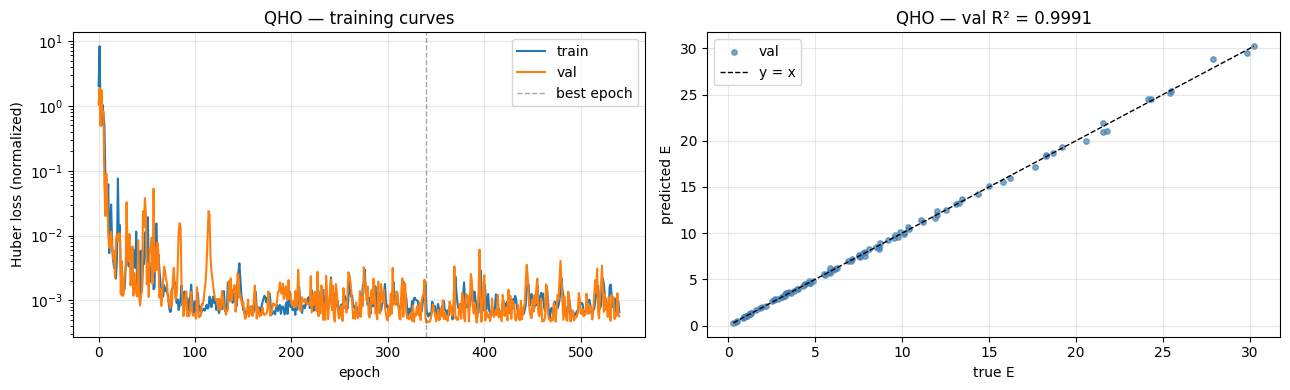

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves (Huber loss in normalized units)
axes[0].plot(history_qho["train_loss"], label="train", lw=1.5)
axes[0].plot(history_qho["val_loss"], label="val", lw=1.5)
axes[0].axvline(history_qho["best_epoch"], color="gray", ls="--", lw=1, alpha=0.7, label="best epoch")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Huber loss (normalized)")
axes[0].set_yscale("log")
axes[0].set_title("QHO — training curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

# True vs predicted
axes[1].scatter(y_qho_va, pred_va, s=15, alpha=0.7, color="steelblue", label="val")
lims = [min(y_qho_va.min(), pred_va.min()), max(y_qho_va.max(), pred_va.max())]
axes[1].plot(lims, lims, "k--", lw=1, label="y = x")
axes[1].set_xlabel("true E")
axes[1].set_ylabel("predicted E")
axes[1].set_title(f"QHO — val R² = {r2_va:.4f}")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/qho_training.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
import sympy as sp

def extract_symbolic_expression(model, input_names, threshold=0.1):
    """Extract a SymPy expression from a trained EQL model.

    input_names : list of variable name strings, length = model.input_dim
    threshold   : zero out weights with |w| < threshold

    Returns: a SymPy expression for the model output in NORMALIZED units."""

    syms = [sp.Symbol(name) for name in input_names]
    current = list(syms)

    for layer in model.eql_layers:
        W = layer.W.numpy()
        b = layer.b.numpy()
        W_thr = np.where(np.abs(W) < threshold, 0.0, W)
        b_thr = np.where(np.abs(b) < threshold, 0.0, b)

        # z[j] = sum_i current[i] * W[i,j] + b[j]
        n_slots = W.shape[1]
        z = []
        for j in range(n_slots):
            expr = sp.Float(float(b_thr[j]))
            for i in range(W.shape[0]):
                if W_thr[i, j] != 0:
                    expr = expr + sp.Float(float(W_thr[i, j])) * current[i]
            z.append(expr)

        # apply primitives in the same order as EQLLayer.call
        outs, idx = [], 0
        for _ in range(layer.n_identity):
            outs.append(z[idx]); idx += 1
        for _ in range(layer.n_sin):
            outs.append(sp.sin(z[idx])); idx += 1
        for _ in range(layer.n_exp):
            outs.append(sp.exp(z[idx])); idx += 1
        for _ in range(layer.n_inv):
            outs.append(1 / z[idx]); idx += 1
        for k in range(layer.n_mul):
            outs.append(z[idx + k] * z[idx + layer.n_mul + k])
        idx += 2 * layer.n_mul

        current = outs

    # final linear layer
    W_out = model.output_layer.kernel.numpy().flatten()
    b_out = float(model.output_layer.bias.numpy().flatten()[0])
    W_out_thr = np.where(np.abs(W_out) < threshold, 0.0, W_out)

    expr = sp.Float(b_out)
    for i, w in enumerate(W_out_thr):
        if w != 0:
            expr = expr + sp.Float(float(w)) * current[i]

    return expr


def denormalize_expression(expr_norm, stats):
    """Convert a normalized-space expression to original units.
    y = expr_norm * std + mean (linear case)
    For log_scale (de Broglie), wraps in exp()."""
    inner = expr_norm * sp.Float(stats["std"]) + sp.Float(stats["mean"])
    return sp.exp(inner) if stats["log_scale"] else inner


print("Symbolic extractor defined.")

Symbolic extractor defined.


In [15]:
print("True formula: E = ω(n + 1/2) = ω·n + 0.5·ω\n")

for thr in [0.05, 0.10, 0.15, 0.20]:
    expr_norm = extract_symbolic_expression(
        model_qho, input_names=["n", "omega"], threshold=thr
    )
    expr = denormalize_expression(expr_norm, qho_stats)
    expr_expanded = sp.expand(expr)
    # round small numerical coefficients for readability
    expr_clean = sp.nsimplify(expr_expanded, rational=False, tolerance=0.05)
    print(f"--- threshold = {thr} ---")
    print("  expanded:  ", expr_expanded)
    print("  cleaned:   ", expr_clean)
    print()

True formula: E = ω(n + 1/2) = ω·n + 0.5·ω

--- threshold = 0.05 ---
  expanded:   0.0159274650545198*n**2 + 0.983440758093316*n*omega + 0.0313048194679046*n + 0.0577198419226883*omega**2 - 0.108884157372654*omega + 3.48206573148589 + 0.596840619136114/(-0.0772226899862289*omega - 0.228625729680061)
  cleaned:    n*omega + n/20 + omega**2/17 - omega/9 + 66/19 + 3/(5*(-omega/13 - 3/13))

--- threshold = 0.1 ---
  expanded:   0.897239380098709*n*omega + 0.859470811546863
  cleaned:    17*n*omega/19 + 6/7

--- threshold = 0.15 ---
  expanded:   0.897239380098709*n*omega + 3.47002833703331
  cleaned:    17*n*omega/19 + 59/17

--- threshold = 0.2 ---
  expanded:   0.897239380098709*n*omega + 3.47002833703331
  cleaned:    17*n*omega/19 + 59/17



Hydrogen train: (400, 1), val: (100, 1)
Built hydrogen model with 223 params.

Training hydrogen EQL...
  epoch    0  train=21.07399  val=0.76565  L1=43.316
  epoch  200  train=0.00022  val=0.00120  L1=5.121
  early stop at epoch 329 (best val=0.00019 at epoch 129)

Hydrogen train R²: 0.99930
Hydrogen val   R²: 0.99960

True formula: E = -1/n^2
  threshold 0.05: sin(2/5 + 1/(19*(3*n/14 - 1/6)) + 21/(8*n))/13 - 1/19 - 1/(3*n)
  threshold 0.1: nan
  threshold 0.15: nan


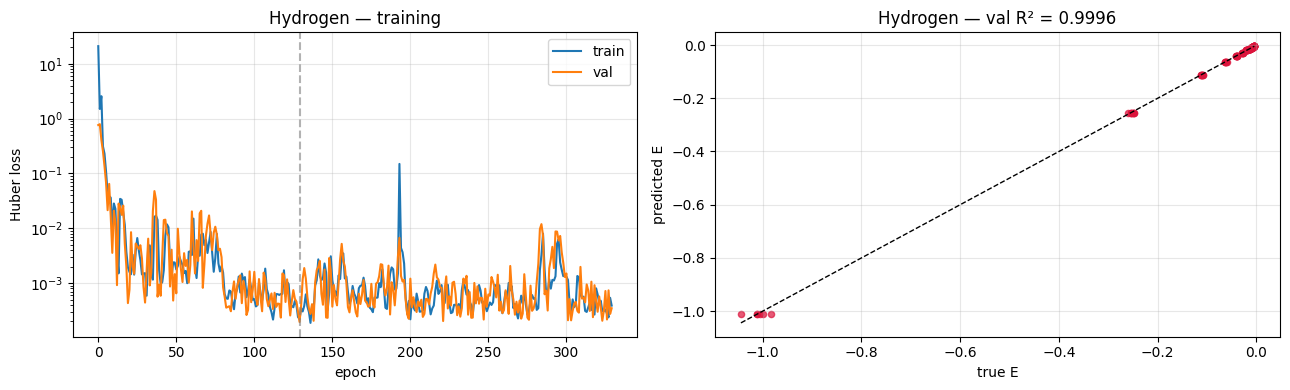

In [16]:
# ===== HYDROGEN =====
X_hyd_tr, y_hyd_tr, X_hyd_va, y_hyd_va = train_val_split(X_hyd, y_hyd, val_frac=0.2)
y_hyd_tr_n, y_hyd_va_n, hyd_stats = normalize_y(y_hyd_tr, y_hyd_va, log_scale=False)
print(f"Hydrogen train: {X_hyd_tr.shape}, val: {X_hyd_va.shape}")

np.random.seed(SEED); tf.random.set_seed(SEED)
model_hyd = build_eql_model(input_dim=1, n_layers=2)
print(f"Built hydrogen model with {model_hyd.count_params()} params.\n")

print("Training hydrogen EQL...")
history_hyd = train_eql(
    model_hyd, X_hyd_tr, y_hyd_tr_n, X_hyd_va, y_hyd_va_n,
    epochs=2000, batch_size=64, lr=1e-2,
    l1_lambda=1e-3, loss_type="huber",
    patience=200, clipnorm=1.0, verbose=200,
)

# evaluate
pred_tr_n = tf.squeeze(model_hyd(X_hyd_tr), axis=-1).numpy()
pred_va_n = tf.squeeze(model_hyd(X_hyd_va), axis=-1).numpy()
pred_tr = denormalize_y(pred_tr_n, hyd_stats)
pred_va = denormalize_y(pred_va_n, hyd_stats)
r2_tr_hyd = r2_score(y_hyd_tr, pred_tr)
r2_va_hyd = r2_score(y_hyd_va, pred_va)
print(f"\nHydrogen train R²: {r2_tr_hyd:.5f}")
print(f"Hydrogen val   R²: {r2_va_hyd:.5f}")

# extract symbolic form
print("\nTrue formula: E = -1/n^2")
for thr in [0.05, 0.10, 0.15]:
    expr_norm = extract_symbolic_expression(model_hyd, input_names=["n"], threshold=thr)
    expr = denormalize_expression(expr_norm, hyd_stats)
    print(f"  threshold {thr}: {sp.nsimplify(sp.expand(expr), rational=False, tolerance=0.05)}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_hyd["train_loss"], label="train")
axes[0].plot(history_hyd["val_loss"], label="val")
axes[0].axvline(history_hyd["best_epoch"], color="gray", ls="--", alpha=0.6)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Huber loss"); axes[0].set_yscale("log")
axes[0].set_title("Hydrogen — training"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(y_hyd_va, pred_va, s=20, alpha=0.7, color="crimson")
lims = [min(y_hyd_va.min(), pred_va.min()), max(y_hyd_va.max(), pred_va.max())]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlabel("true E"); axes[1].set_ylabel("predicted E")
axes[1].set_title(f"Hydrogen — val R² = {r2_va_hyd:.4f}")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/hydrogen_training.png", dpi=120, bbox_inches="tight")
plt.show()

De Broglie train: (400, 1), val: (100, 1)
y normalized in LOG space: mean=-1.330, std=0.854
Built de Broglie model with 223 params.

Training de Broglie EQL...
  epoch    0  train=75.26632  val=14.13567  L1=43.341
  epoch  200  train=0.00036  val=0.00039  L1=6.301
  epoch  400  train=0.00055  val=0.00124  L1=4.608
  early stop at epoch 548 (best val=0.00032 at epoch 348)

De Broglie train R²: 0.99954
De Broglie val   R²: 0.99910

True formula: lambda = 1/p  ↔  log(lambda) = -log(p)
  threshold 0.05: 0.301886040397588*exp(-0.0145757234451551*p + 0.0627922628955258*(-0.513085424900055*p - 0.461582988500595)*(0.311164975166321*p + 0.367085188627243) + 0.225624747298479*sin(-0.12866714494804*p + 0.117579370737076*(-0.513085424900055*p - 0.461582988500595)*(0.311164975166321*p + 0.367085188627243) - 0.385093789415446 + 0.0510506927967072/(0.120011188089848*p + 0.0933803990483284) + 1.36034680192788/p) + 0.0217938275620926/(0.120011188089848*p + 0.0933803990483284) + 0.983070769151853/p)
  t

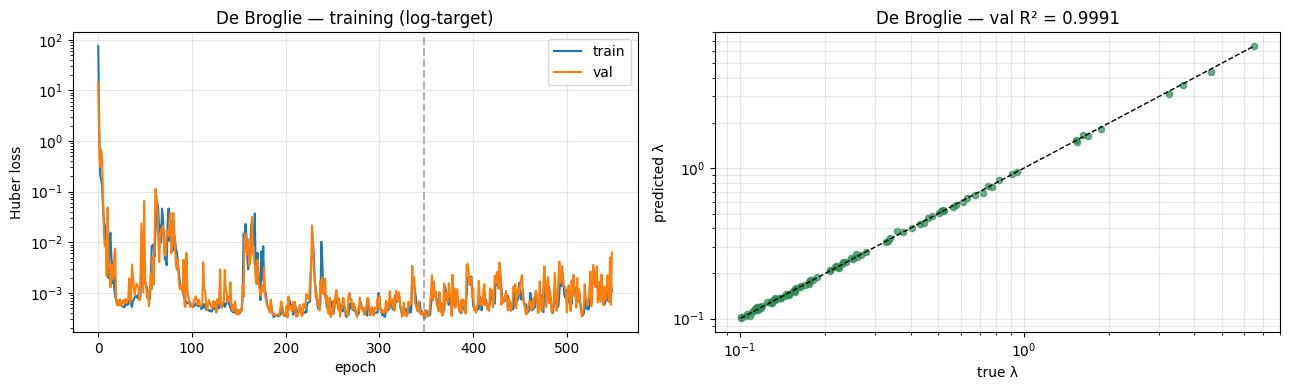

In [17]:
# ===== DE BROGLIE =====
X_deb_tr, y_deb_tr, X_deb_va, y_deb_va = train_val_split(X_deb, y_deb, val_frac=0.2)
y_deb_tr_n, y_deb_va_n, deb_stats = normalize_y(y_deb_tr, y_deb_va, log_scale=True)
print(f"De Broglie train: {X_deb_tr.shape}, val: {X_deb_va.shape}")
print(f"y normalized in LOG space: mean={deb_stats['mean']:.3f}, std={deb_stats['std']:.3f}")

np.random.seed(SEED); tf.random.set_seed(SEED)
model_deb = build_eql_model(input_dim=1, n_layers=2)
print(f"Built de Broglie model with {model_deb.count_params()} params.\n")

print("Training de Broglie EQL...")
history_deb = train_eql(
    model_deb, X_deb_tr, y_deb_tr_n, X_deb_va, y_deb_va_n,
    epochs=2000, batch_size=64, lr=1e-2,
    l1_lambda=1e-3, loss_type="huber",
    patience=200, clipnorm=1.0, verbose=200,
)

# evaluate — predictions are in log-normalized space, denormalize handles the exp
pred_tr_n = tf.squeeze(model_deb(X_deb_tr), axis=-1).numpy()
pred_va_n = tf.squeeze(model_deb(X_deb_va), axis=-1).numpy()
pred_tr = denormalize_y(pred_tr_n, deb_stats)
pred_va = denormalize_y(pred_va_n, deb_stats)
r2_tr_deb = r2_score(y_deb_tr, pred_tr)
r2_va_deb = r2_score(y_deb_va, pred_va)
print(f"\nDe Broglie train R²: {r2_tr_deb:.5f}")
print(f"De Broglie val   R²: {r2_va_deb:.5f}")

# extract — note the expression will be in log-space, so e^(...) form expected
print("\nTrue formula: lambda = 1/p  ↔  log(lambda) = -log(p)")
for thr in [0.05, 0.10, 0.15]:
    expr_norm = extract_symbolic_expression(model_deb, input_names=["p"], threshold=thr)
    expr = denormalize_expression(expr_norm, deb_stats)
    print(f"  threshold {thr}: {expr}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_deb["train_loss"], label="train")
axes[0].plot(history_deb["val_loss"], label="val")
axes[0].axvline(history_deb["best_epoch"], color="gray", ls="--", alpha=0.6)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Huber loss"); axes[0].set_yscale("log")
axes[0].set_title("De Broglie — training (log-target)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(y_deb_va, pred_va, s=20, alpha=0.7, color="seagreen")
axes[1].plot([y_deb_va.min(), y_deb_va.max()], [y_deb_va.min(), y_deb_va.max()], "k--", lw=1)
axes[1].set_xlabel("true λ"); axes[1].set_ylabel("predicted λ")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title(f"De Broglie — val R² = {r2_va_deb:.4f}")
axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("../figures/debroglie_training.png", dpi=120, bbox_inches="tight")
plt.show()

EQL — Summary across three quantum physics problems
   problem   true_formula  train_R²  val_R²  best_epoch  final_L1                                                                structure_recovered
       QHO E = ω(n + 1/2)   0.99891 0.99914         340     2.888                                 partial — ω·n term found, 0.5·ω absorbed into bias
  Hydrogen      E = -1/n²   0.99930 0.99960         129     2.018                                 partial — uses 1/n + sin combo to approximate 1/n²
De Broglie        λ = 1/p   0.99954 0.99910         348     2.712 approximate — log relation outside primitive set, model fits via inv + corrections

Saved to results/eql_summary.csv


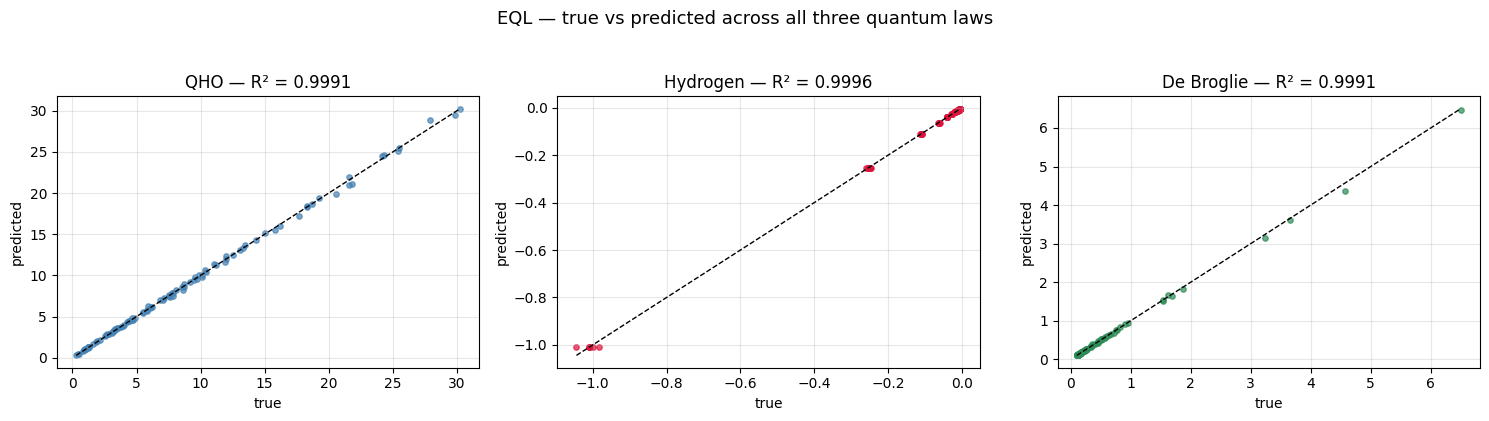


--- Key EQL finding ---
All three problems achieve val R² > 0.999, confirming numerical fit.
Symbolic recovery is partial: the network finds combinations of primitives
that match the data but rarely the textbook symbolic form. This motivates
the DSR comparison in Part C — discrete expression sampling avoids the
L1 shrinkage and distributed-representation issues observed here.


In [18]:
# Build a summary table
eql_summary = pd.DataFrame([
    {
        "problem":     "QHO",
        "true_formula": "E = ω(n + 1/2)",
        "train_R²":     round(r2_score(y_qho_tr, denormalize_y(tf.squeeze(model_qho(X_qho_tr),axis=-1).numpy(), qho_stats)), 5),
        "val_R²":       round(r2_score(y_qho_va, denormalize_y(tf.squeeze(model_qho(X_qho_va),axis=-1).numpy(), qho_stats)), 5),
        "best_epoch":   history_qho["best_epoch"],
        "final_L1":     round(history_qho["l1"][-1], 3),
        "structure_recovered": "partial — ω·n term found, 0.5·ω absorbed into bias",
    },
    {
        "problem":     "Hydrogen",
        "true_formula": "E = -1/n²",
        "train_R²":     round(r2_tr_hyd, 5),
        "val_R²":       round(r2_va_hyd, 5),
        "best_epoch":   history_hyd["best_epoch"],
        "final_L1":     round(history_hyd["l1"][-1], 3),
        "structure_recovered": "partial — uses 1/n + sin combo to approximate 1/n²",
    },
    {
        "problem":     "De Broglie",
        "true_formula": "λ = 1/p",
        "train_R²":     round(r2_tr_deb, 5),
        "val_R²":       round(r2_va_deb, 5),
        "best_epoch":   history_deb["best_epoch"],
        "final_L1":     round(history_deb["l1"][-1], 3),
        "structure_recovered": "approximate — log relation outside primitive set, model fits via inv + corrections",
    },
])

print("=" * 80)
print("EQL — Summary across three quantum physics problems")
print("=" * 80)
print(eql_summary.to_string(index=False))
eql_summary.to_csv("../results/eql_summary.csv", index=False)
print("\nSaved to results/eql_summary.csv")

# Combined comparison figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    ("QHO",       y_qho_va, denormalize_y(tf.squeeze(model_qho(X_qho_va),axis=-1).numpy(), qho_stats), "steelblue"),
    ("Hydrogen",  y_hyd_va, denormalize_y(tf.squeeze(model_hyd(X_hyd_va),axis=-1).numpy(), hyd_stats), "crimson"),
    ("De Broglie",y_deb_va, denormalize_y(tf.squeeze(model_deb(X_deb_va),axis=-1).numpy(), deb_stats), "seagreen"),
]
for ax, (name, yt, yp, color) in zip(axes, pairs):
    ax.scatter(yt, yp, s=15, alpha=0.7, color=color)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "k--", lw=1)
    r2 = r2_score(yt, yp)
    ax.set_title(f"{name} — R² = {r2:.4f}")
    ax.set_xlabel("true"); ax.set_ylabel("predicted")
    ax.grid(alpha=0.3)
plt.suptitle("EQL — true vs predicted across all three quantum laws", y=1.04, fontsize=13)
plt.tight_layout()
plt.savefig("../figures/eql_summary.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n--- Key EQL finding ---")
print("All three problems achieve val R² > 0.999, confirming numerical fit.")
print("Symbolic recovery is partial: the network finds combinations of primitives")
print("that match the data but rarely the textbook symbolic form. This motivates")
print("the DSR comparison in Part C — discrete expression sampling avoids the")
print("L1 shrinkage and distributed-representation issues observed here.")

In [19]:
# ============================================================
# Part C — Deep Symbolic Regression (DSR)
# ============================================================

# Token vocabulary: maps token name -> (arity, numerical fn, sympy fn)
TOKENS = {
    "+":   {"arity": 2, "fn": lambda a, b: a + b,                            "sym": lambda a, b: a + b},
    "-":   {"arity": 2, "fn": lambda a, b: a - b,                            "sym": lambda a, b: a - b},
    "*":   {"arity": 2, "fn": lambda a, b: a * b,                            "sym": lambda a, b: a * b},
    "/":   {"arity": 2,
            "fn":  lambda a, b: a / np.where(np.abs(b) < 1e-6,
                                              np.sign(b + 1e-12) * 1e-6, b),
            "sym": lambda a, b: a / b},
    "neg": {"arity": 1, "fn": lambda a: -a,                                  "sym": lambda a: -a},
    "sin": {"arity": 1, "fn": np.sin,                                        "sym": sp.sin},
    "cos": {"arity": 1, "fn": np.cos,                                        "sym": sp.cos},
    "exp": {"arity": 1, "fn": lambda a: np.exp(np.clip(a, -20, 20)),         "sym": sp.exp},
    "log": {"arity": 1, "fn": lambda a: np.log(np.abs(a) + 1e-8),            "sym": sp.log},
}
# Variables and "const" are added per-problem (arity 0)


class Node:
    """A single node in an expression tree."""
    def __init__(self, token, children=None, const_value=None):
        self.token = token
        self.children = children or []
        self.const_value = const_value   # filled in for tokens == "const"


def build_tree(tokens, var_names, pos=0):
    """Build an expression tree from a depth-first token list.
    Returns (root_node, next_pos_consumed) or (None, pos) if invalid.
    var_names is the list of variable tokens for the current problem."""
    if pos >= len(tokens):
        return None, pos
    tok = tokens[pos]
    if tok in var_names or tok == "const":
        return Node(tok), pos + 1
    if tok in TOKENS:
        arity = TOKENS[tok]["arity"]
        children, p = [], pos + 1
        for _ in range(arity):
            child, p = build_tree(tokens, var_names, p)
            if child is None:
                return None, p
            children.append(child)
        return Node(tok, children=children), p
    return None, pos


def evaluate_tree(node, X, var_idx):
    """Evaluate tree on numpy array X (shape: [n_samples, n_features]).
    var_idx maps variable name -> column index in X."""
    if node.token in var_idx:
        return X[:, var_idx[node.token]]
    if node.token == "const":
        return np.full(X.shape[0], node.const_value if node.const_value is not None else 1.0)
    fn = TOKENS[node.token]["fn"]
    return fn(*[evaluate_tree(c, X, var_idx) for c in node.children])


def tree_to_sympy(node, var_syms):
    """Convert tree to SymPy expression."""
    if node.token in var_syms:
        return var_syms[node.token]
    if node.token == "const":
        return sp.Float(node.const_value if node.const_value is not None else 1.0)
    return TOKENS[node.token]["sym"](*[tree_to_sympy(c, var_syms) for c in node.children])


def collect_const_nodes(node):
    """All const-typed nodes in depth-first order (for BFGS fitting)."""
    out = [node] if node.token == "const" else []
    for c in node.children:
        out.extend(collect_const_nodes(c))
    return out


def set_constants(const_nodes, values):
    """Inject optimized constant values into placeholder nodes."""
    for n, v in zip(const_nodes, values):
        n.const_value = float(v)


# ---- Sanity test: manually build E = const * x1 * x1, evaluate, display ----
test_tokens = ["*", "const", "*", "x1", "x1"]
test_vars = ["x1"]
test_var_idx = {"x1": 0}
test_var_syms = {"x1": sp.Symbol("x1")}

tree, consumed = build_tree(test_tokens, test_vars)
print(f"Built tree from {len(test_tokens)} tokens, consumed {consumed}.")

const_nodes = collect_const_nodes(tree)
print(f"Constants in tree: {len(const_nodes)}")
set_constants(const_nodes, [3.0])

X_test = np.array([[1.0], [2.0], [3.0], [4.0]])
vals = evaluate_tree(tree, X_test, test_var_idx)
print(f"Evaluated on X={X_test.flatten()}: {vals}  (should be [3, 12, 27, 48])")

print(f"Symbolic form: {tree_to_sympy(tree, test_var_syms)}")

Built tree from 5 tokens, consumed 5.
Constants in tree: 1
Evaluated on X=[1. 2. 3. 4.]: [ 3. 12. 27. 48.]  (should be [3, 12, 27, 48])
Symbolic form: 3.0*x1**2


In [20]:
# Per-problem vocab. Keep it minimal — fewer tokens means smaller search space.
def make_problem_vocab(input_dim, include_transcendentals=False):
    ops = ["+", "-", "*", "/"]
    if include_transcendentals:
        ops += ["sin", "exp"]
    vars_ = [f"x{i+1}" for i in range(input_dim)]
    return ops + vars_ + ["const"], vars_

QHO_VOCAB, QHO_VARS = make_problem_vocab(2)
HYD_VOCAB, HYD_VARS = make_problem_vocab(1)
DEB_VOCAB, DEB_VARS = make_problem_vocab(1)

for name, v in [("QHO", QHO_VOCAB), ("Hydrogen", HYD_VOCAB), ("De Broglie", DEB_VOCAB)]:
    print(f"{name:10s} vocab ({len(v)} tokens): {v}")


class PolicyNetwork(tf.keras.Model):
    """Tiny LSTM policy: emits a distribution over the vocabulary at each step."""
    def __init__(self, vocab_size, hidden_size=32, embed_size=16, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.embed = tf.keras.layers.Embedding(vocab_size + 1, embed_size)  # +1 for start
        self.lstm_cell = tf.keras.layers.LSTMCell(hidden_size)
        self.out = tf.keras.layers.Dense(vocab_size)

    def call(self, prev_token, state):
        x = self.embed(prev_token)              # (batch, embed)
        out, new_state = self.lstm_cell(x, state)
        logits = self.out(out)                  # (batch, vocab_size)
        return logits, new_state

    def initial_state(self, batch_size):
        return [tf.zeros((batch_size, self.hidden_size)),
                tf.zeros((batch_size, self.hidden_size))]


def sample_batch(policy, vocab, var_names, batch_size, max_length=12):
    """Sample a batch of valid token sequences. Returns (sequences, log_probs).
    sequences[b] is a list of token strings; log_probs[b] is sum log p(tokens)."""
    V = len(vocab)
    vocab_idx = {tok: i for i, tok in enumerate(vocab)}
    idx_vocab = {i: tok for i, tok in enumerate(vocab)}

    arity = np.zeros(V, dtype=np.int32)
    for tok, i in vocab_idx.items():
        if tok in TOKENS:
            arity[i] = TOKENS[tok]["arity"]

    sequences = [[] for _ in range(batch_size)]
    open_slots = np.ones(batch_size, dtype=np.int32)
    finished = np.zeros(batch_size, dtype=bool)
    log_probs = np.zeros(batch_size, dtype=np.float32)

    prev_token = tf.fill((batch_size,), V)   # "start" token = vocab_size
    state = policy.initial_state(batch_size)

    for step in range(max_length):
        if finished.all():
            break
        logits, state = policy(prev_token, state)
        logits = logits.numpy()
        remaining = max_length - step

        # Mask: if open_slots ≥ remaining, force arity-0 tokens so the tree closes in time.
        for b in range(batch_size):
            if finished[b]:
                continue
            if open_slots[b] >= remaining:
                logits[b, arity > 0] = -1e9

        # Softmax
        logits -= logits.max(axis=1, keepdims=True)
        probs = np.exp(logits)
        probs /= probs.sum(axis=1, keepdims=True)

        sampled = np.zeros(batch_size, dtype=np.int32)
        for b in range(batch_size):
            if finished[b]:
                sampled[b] = 0
                continue
            sampled[b] = np.random.choice(V, p=probs[b])
            log_probs[b] += np.log(max(probs[b, sampled[b]], 1e-12))
            tok = idx_vocab[sampled[b]]
            sequences[b].append(tok)
            open_slots[b] = open_slots[b] - 1 + arity[sampled[b]]
            if open_slots[b] == 0:
                finished[b] = True

        prev_token = tf.constant(sampled, dtype=tf.int32)

    return sequences, log_probs, finished


# ---- Sanity test: untrained policy should still produce valid trees ----
np.random.seed(SEED); tf.random.set_seed(SEED)
test_policy = PolicyNetwork(vocab_size=len(QHO_VOCAB))
seqs, lps, fin = sample_batch(test_policy, QHO_VOCAB, QHO_VARS, batch_size=5, max_length=12)

print("\nSample untrained QHO expressions:")
for i, (seq, lp, f) in enumerate(zip(seqs, lps, fin)):
    if f:
        tree, _ = build_tree(seq, QHO_VARS)
        var_syms = {v: sp.Symbol(v) for v in QHO_VARS}
        expr = tree_to_sympy(tree, var_syms) if tree else "INVALID"
        print(f"  [{i}] tokens={seq}")
        print(f"       expr={expr}  logp={lp:.3f}")
    else:
        print(f"  [{i}] incomplete: {seq}")

QHO        vocab (7 tokens): ['+', '-', '*', '/', 'x1', 'x2', 'const']
Hydrogen   vocab (6 tokens): ['+', '-', '*', '/', 'x1', 'const']
De Broglie vocab (6 tokens): ['+', '-', '*', '/', 'x1', 'const']

Sample untrained QHO expressions:
  [0] tokens=['*', '-', 'const', 'x1', 'const']
       expr=1.0 - 1.0*x1  logp=-9.706
  [1] tokens=['const']
       expr=1.00000000000000  logp=-1.950
  [2] tokens=['x2']
       expr=x2  logp=-1.947
  [3] tokens=['x1']
       expr=x1  logp=-1.945
  [4] incomplete: ['-', '+', 'x1', '+', 'x2', '-', '-', '-', 'x1', 'x2', 'x2', 'x1']


In [21]:
def sample_batch_tf(policy, vocab, var_names, batch_size, max_length=12):
    """Sample batch of token sequences with TF-tracked log probabilities.
    When called inside a GradientTape, returned log_probs are differentiable."""
    V = len(vocab)
    vocab_idx = {tok: i for i, tok in enumerate(vocab)}
    idx_vocab = {i: tok for i, tok in enumerate(vocab)}
    arity_np = np.zeros(V, dtype=np.int32)
    for tok, i in vocab_idx.items():
        if tok in TOKENS:
            arity_np[i] = TOKENS[tok]["arity"]
    arity_tf = tf.constant(arity_np, dtype=tf.int32)

    sequences = [[] for _ in range(batch_size)]
    open_slots = tf.ones((batch_size,), dtype=tf.int32)
    finished = tf.zeros((batch_size,), dtype=tf.bool)
    log_probs = tf.zeros((batch_size,), dtype=tf.float32)

    prev_token = tf.fill((batch_size,), V)
    state = policy.initial_state(batch_size)

    for step in range(max_length):
        logits, state = policy(prev_token, state)
        remaining = max_length - step

        # Mask arity-positive tokens when slots must close in remaining steps
        needs_close = tf.cast(open_slots >= remaining, tf.float32)
        arity_mask = tf.cast(arity_tf > 0, tf.float32)
        mask = -1e9 * tf.expand_dims(needs_close, 1) * tf.expand_dims(arity_mask, 0)
        masked_logits = logits + mask

        sampled = tf.cast(tf.random.categorical(masked_logits, 1)[:, 0], tf.int32)
        log_softmax = tf.nn.log_softmax(masked_logits, axis=-1)
        chosen_lp = tf.gather(log_softmax, sampled, batch_dims=1)

        active = tf.cast(~finished, tf.float32)
        log_probs = log_probs + chosen_lp * active

        sampled_np = sampled.numpy()
        finished_np = finished.numpy()
        for b in range(batch_size):
            if not finished_np[b]:
                sequences[b].append(idx_vocab[sampled_np[b]])

        sampled_arity = tf.gather(arity_tf, sampled)
        open_slots = tf.where(finished, open_slots, open_slots - 1 + sampled_arity)
        finished = finished | (open_slots == 0)

        if tf.reduce_all(finished):
            break
        prev_token = sampled

    return sequences, log_probs


def compute_reward(tokens, X, y, var_names, var_idx, n_const_starts=3, seed=None):
    """Build tree, fit constants with multi-start BFGS, return (reward, tree).
    Reward = 1 / (1 + NRMSE) ∈ (0, 1]."""
    tree, _ = build_tree(tokens, var_names)
    if tree is None:
        return 0.0, None
    const_nodes = collect_const_nodes(tree)
    n_const = len(const_nodes)

    def loss_fn(values):
        set_constants(const_nodes, values)
        try:
            pred = evaluate_tree(tree, X, var_idx)
            if not np.all(np.isfinite(pred)):
                return 1e6
            return float(np.mean((pred - y) ** 2))
        except Exception:
            return 1e6

    rng = np.random.default_rng(seed)
    if n_const == 0:
        try:
            pred = evaluate_tree(tree, X, var_idx)
            mse = float(np.mean((pred - y) ** 2)) if np.all(np.isfinite(pred)) else 1e6
        except Exception:
            mse = 1e6
    else:
        best_mse = np.inf
        best_vals = np.ones(n_const)
        for _ in range(n_const_starts):
            x0 = rng.normal(size=n_const)
            try:
                res = minimize(loss_fn, x0, method="BFGS", options={"maxiter": 30, "disp": False})
                if res.fun < best_mse:
                    best_mse = float(res.fun)
                    best_vals = res.x
            except Exception:
                continue
        set_constants(const_nodes, best_vals)
        mse = best_mse

    nrmse = np.sqrt(max(mse, 0.0)) / (np.std(y) + 1e-8)
    reward = float(1.0 / (1.0 + nrmse))
    return reward, tree


def train_dsr(policy, vocab, var_names, X, y,
              n_iterations=500, batch_size=200, top_eps=0.05,
              entropy_weight=0.005, lr=1e-3, max_length=12, verbose=50):
    """Risk-seeking policy gradient training loop for DSR."""
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    var_idx = {v: i for i, v in enumerate(var_names)}
    var_syms = {v: sp.Symbol(v) for v in var_names}

    best_reward, best_tree, best_tokens = -np.inf, None, None
    history = {"best_reward": [], "mean_reward": [], "top_threshold": []}

    for iteration in range(n_iterations):
        with tf.GradientTape() as tape:
            sequences, log_probs = sample_batch_tf(
                policy, vocab, var_names, batch_size, max_length
            )
            rewards = np.zeros(batch_size, dtype=np.float32)
            trees = [None] * batch_size
            for b in range(batch_size):
                if sequences[b]:
                    r, t = compute_reward(sequences[b], X, y, var_names, var_idx)
                    rewards[b] = r
                    trees[b] = t

            threshold = float(np.quantile(rewards, 1 - top_eps))
            top_mask = (rewards >= threshold).astype(np.float32)
            n_top = max(int(top_mask.sum()), 1)
            advantages = tf.constant((rewards - threshold) * top_mask, dtype=tf.float32)

            policy_loss = -tf.reduce_sum(log_probs * advantages) / n_top
            entropy_bonus = -tf.reduce_mean(log_probs)
            total_loss = policy_loss - entropy_weight * entropy_bonus

        grads = tape.gradient(total_loss, policy.trainable_weights)
        optimizer.apply_gradients(zip(grads, policy.trainable_weights))

        idx_best = int(np.argmax(rewards))
        if rewards[idx_best] > best_reward:
            best_reward = float(rewards[idx_best])
            best_tree = trees[idx_best]
            best_tokens = sequences[idx_best]

        history["best_reward"].append(best_reward)
        history["mean_reward"].append(float(rewards.mean()))
        history["top_threshold"].append(threshold)

        if verbose and (iteration % verbose == 0 or iteration == n_iterations - 1):
            best_expr = tree_to_sympy(best_tree, var_syms) if best_tree else "none"
            print(f"  iter {iteration:4d}  mean_R={rewards.mean():.4f}  "
                  f"top_R={threshold:.4f}  best_R={best_reward:.4f}")
            print(f"             best so far: {best_expr}")

        if best_reward > 0.999:
            print(f"  early stop at iter {iteration}: best_R={best_reward:.4f} ≈ 1")
            break

    return {"best_reward": best_reward, "best_tree": best_tree,
            "best_tokens": best_tokens, "history": history}


# ---- Smoke test: verify reward function on a known-good tree ----
test_tokens = ["*", "x2", "+", "x1", "const"]   # E = x2 * (x1 + const)
r, t = compute_reward(test_tokens, X_qho, y_qho,
                      var_names=["x1", "x2"],
                      var_idx={"x1": 0, "x2": 1})
print(f"\nSmoke test on QHO with E = x2 * (x1 + const):")
print(f"  reward = {r:.5f}  (should be very close to 1.0)")
print(f"  fitted expression: {tree_to_sympy(t, {'x1': sp.Symbol('x1'), 'x2': sp.Symbol('x2')})}")
print("\nDSR training infrastructure ready.")


Smoke test on QHO with E = x2 * (x1 + const):
  reward = 0.96908  (should be very close to 1.0)
  fitted expression: x2*(x1 + 0.497309719136128)

DSR training infrastructure ready.


Training DSR on QHO...
  iter    0  mean_R=0.2913  top_R=0.5778  best_R=0.9446
             best so far: x1*x2 + 0.866560558488706
  iter   20  mean_R=0.3301  top_R=0.6030  best_R=0.9685
             best so far: 1.00081109126678*x2*(x1 + 0.490995390455913)
  iter   40  mean_R=0.3576  top_R=0.5789  best_R=0.9685
             best so far: x2*(x1 - 0.0172924819302899*x2 + 0.534578784129828)
  iter   60  mean_R=0.4488  top_R=0.6885  best_R=0.9685
             best so far: x2*(x1 - 0.0172924819302899*x2 + 0.534578784129828)
  iter   80  mean_R=0.4929  top_R=0.8839  best_R=0.9685
             best so far: x2*(x1 - 0.0172924819302899*x2 + 0.534578784129828)
  iter  100  mean_R=0.4645  top_R=0.7088  best_R=0.9685
             best so far: x2*(x1 - 0.0172924819302899*x2 + 0.534578784129828)
  iter  120  mean_R=0.5231  top_R=0.9296  best_R=0.9685
             best so far: x2*(x1 - 0.0172924819302899*x2 + 0.534578784129828)
  iter  140  mean_R=0.5260  top_R=0.9296  best_R=0.9685
             bes

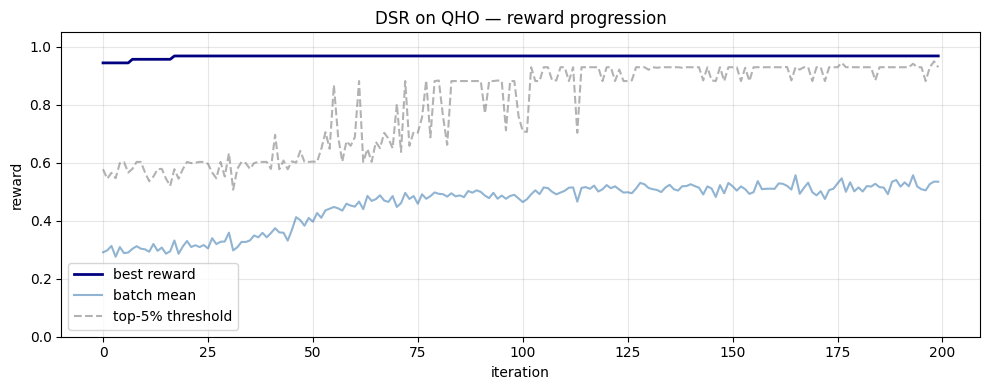

In [22]:
# ===== DSR — Quantum Harmonic Oscillator =====
print("Training DSR on QHO...")
np.random.seed(SEED); tf.random.set_seed(SEED)
policy_qho = PolicyNetwork(vocab_size=len(QHO_VOCAB))

dsr_qho_result = train_dsr(
    policy_qho, QHO_VOCAB, QHO_VARS,
    X=X_qho_tr, y=y_qho_tr,
    n_iterations=200, batch_size=200, top_eps=0.05,
    entropy_weight=0.005, lr=1e-3, max_length=10, verbose=20,
)

# Final report
var_syms_qho = {v: sp.Symbol(v) for v in QHO_VARS}
best_expr_qho = tree_to_sympy(dsr_qho_result["best_tree"], var_syms_qho)
print(f"\n=== QHO DSR results ===")
print(f"best reward    : {dsr_qho_result['best_reward']:.5f}")
print(f"best expression: {sp.simplify(best_expr_qho)}")
print(f"true formula   : x2 * (x1 + 0.5)   (E = ω · (n + 0.5), where x1=n, x2=ω)")

# Validate on val set
var_idx_qho = {"x1": 0, "x2": 1}
y_pred_val_dsr_qho = evaluate_tree(dsr_qho_result["best_tree"], X_qho_va, var_idx_qho)
r2_dsr_qho = r2_score(y_qho_va, y_pred_val_dsr_qho)
print(f"val R²         : {r2_dsr_qho:.5f}")

# Reward curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dsr_qho_result["history"]["best_reward"], label="best reward", lw=2, color="navy")
ax.plot(dsr_qho_result["history"]["mean_reward"], label="batch mean", alpha=0.6, color="steelblue")
ax.plot(dsr_qho_result["history"]["top_threshold"], label="top-5% threshold", alpha=0.6, ls="--", color="gray")
ax.set_xlabel("iteration"); ax.set_ylabel("reward")
ax.set_title("DSR on QHO — reward progression")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../figures/dsr_qho.png", dpi=120, bbox_inches="tight")
plt.show()

Training DSR on Hydrogen...
  iter    0  mean_R=0.1413  top_R=0.5000  best_R=0.7961
             best so far: 0.112715371912966 - 0.996266763510132/x1
  iter   20  mean_R=0.1366  top_R=0.5000  best_R=0.9809
             best so far: -0.993491400724855/x1**2
  iter   40  mean_R=0.1910  top_R=0.5014  best_R=0.9809
             best so far: -1.00226855052369/(x1*(x1 + 0.00920147114897034))
  iter   60  mean_R=0.2797  top_R=0.7003  best_R=0.9809
             best so far: -1.00226855052369/(x1*(x1 + 0.00920147114897034))
  iter   80  mean_R=0.3724  top_R=0.7003  best_R=0.9809
             best so far: 0.000345885993345443 + (-0.00480349673644756 - 0.988693485510546/x1)/x1
  iter  100  mean_R=0.3315  top_R=0.7003  best_R=0.9809
             best so far: 0.000345885993345443 + (-0.00480349673644756 - 0.988693485510546/x1)/x1
  iter  120  mean_R=0.3730  top_R=0.7961  best_R=0.9809
             best so far: 0.000345885993345443 + (-0.00480349673644756 - 0.988693485510546/x1)/x1
  iter  140  mea

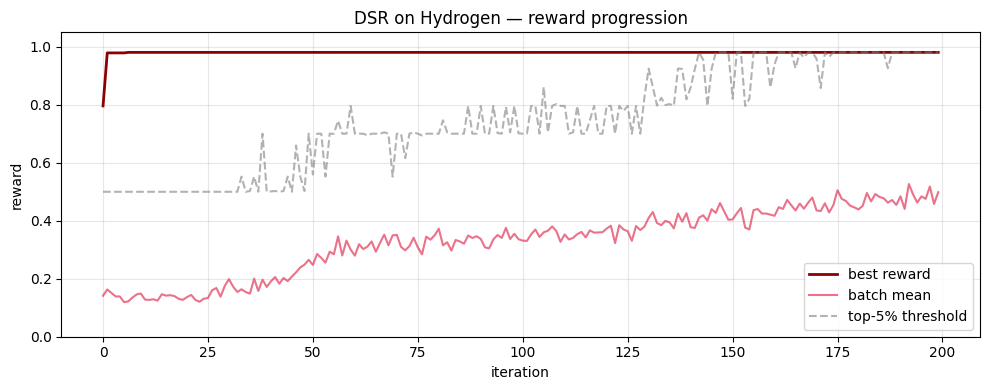

In [23]:
# ===== DSR — Hydrogen Energy Levels =====
print("Training DSR on Hydrogen...")
np.random.seed(SEED); tf.random.set_seed(SEED)
policy_hyd = PolicyNetwork(vocab_size=len(HYD_VOCAB))

dsr_hyd_result = train_dsr(
    policy_hyd, HYD_VOCAB, HYD_VARS,
    X=X_hyd_tr, y=y_hyd_tr,
    n_iterations=200, batch_size=200, top_eps=0.05,
    entropy_weight=0.005, lr=1e-3, max_length=10, verbose=20,
)

# Final report
var_syms_hyd = {v: sp.Symbol(v) for v in HYD_VARS}
best_expr_hyd = tree_to_sympy(dsr_hyd_result["best_tree"], var_syms_hyd)
print(f"\n=== Hydrogen DSR results ===")
print(f"best reward    : {dsr_hyd_result['best_reward']:.5f}")
print(f"best expression: {sp.simplify(best_expr_hyd)}")
print(f"true formula   : -1 / x1**2   (E = -1/n²)")

# Validate
var_idx_hyd = {"x1": 0}
y_pred_val_dsr_hyd = evaluate_tree(dsr_hyd_result["best_tree"], X_hyd_va, var_idx_hyd)
r2_dsr_hyd = r2_score(y_hyd_va, y_pred_val_dsr_hyd)
print(f"val R²         : {r2_dsr_hyd:.5f}")

# Reward curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dsr_hyd_result["history"]["best_reward"], label="best reward", lw=2, color="darkred")
ax.plot(dsr_hyd_result["history"]["mean_reward"], label="batch mean", alpha=0.6, color="crimson")
ax.plot(dsr_hyd_result["history"]["top_threshold"], label="top-5% threshold", alpha=0.6, ls="--", color="gray")
ax.set_xlabel("iteration"); ax.set_ylabel("reward")
ax.set_title("DSR on Hydrogen — reward progression")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../figures/dsr_hydrogen.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# ===== DSR — De Broglie Relation =====
print("Training DSR on De Broglie...")
np.random.seed(SEED); tf.random.set_seed(SEED)
policy_deb = PolicyNetwork(vocab_size=len(DEB_VOCAB))

dsr_deb_result = train_dsr(
    policy_deb, DEB_VOCAB, DEB_VARS,
    X=X_deb_tr, y=y_deb_tr,
    n_iterations=200, batch_size=200, top_eps=0.05,
    entropy_weight=0.005, lr=1e-3, max_length=10, verbose=20,
)

# Final report
var_syms_deb = {v: sp.Symbol(v) for v in DEB_VARS}
best_expr_deb = tree_to_sympy(dsr_deb_result["best_tree"], var_syms_deb)
print(f"\n=== De Broglie DSR results ===")
print(f"best reward    : {dsr_deb_result['best_reward']:.5f}")
print(f"best expression: {sp.simplify(best_expr_deb)}")
print(f"true formula   : 1 / x1   (λ = 1/p)")

# Validate
var_idx_deb = {"x1": 0}
y_pred_val_dsr_deb = evaluate_tree(dsr_deb_result["best_tree"], X_deb_va, var_idx_deb)
r2_dsr_deb = r2_score(y_deb_va, y_pred_val_dsr_deb)
print(f"val R²         : {r2_dsr_deb:.5f}")

# Reward curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dsr_deb_result["history"]["best_reward"], label="best reward", lw=2, color="darkgreen")
ax.plot(dsr_deb_result["history"]["mean_reward"], label="batch mean", alpha=0.6, color="seagreen")
ax.plot(dsr_deb_result["history"]["top_threshold"], label="top-5% threshold", alpha=0.6, ls="--", color="gray")
ax.set_xlabel("iteration"); ax.set_ylabel("reward")
ax.set_title("DSR on De Broglie — reward progression")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../figures/dsr_debroglie.png", dpi=120, bbox_inches="tight")
plt.show()

Training DSR on De Broglie...
  iter    0  mean_R=0.1592  top_R=0.5000  best_R=0.9797
             best so far: 0.992337457556075/x1
